In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [2]:
import gym
import d4rl # Import required to register environments, you may need to also import the submodule

# Create the environment
env = gym.make('antmaze-large-diverse-v2')
dataset = env.get_dataset()

/home/nazim/.local/lib/python3.10/site-packages/gym/wrappers/monitoring/video_recorder.py:9: DeprecationWarning: The distutils package is deprecated and slated for removal in Python 3.12. Use setuptools or check PEP 632 for potential alternatives
  import distutils.spawn
/home/nazim/.local/lib/python3.10/site-packages/mujoco_py/builder.py:9: DeprecationWarning: The distutils.sysconfig module is deprecated, use sysconfig instead
  from distutils.sysconfig import customize_compiler
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead
No module named 'flow'
No module named 'carla'
pybullet build time: Jan 29 2025 23:16:28
/home/nazim/.local/lib/python3.10/site-packages/gym/spaces/box.py:84: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Target Goal:  (33.15742899989547, 24.564810416362583)


load datafile: 100%|██████████| 8/8 [00:01<00:00,  5.45it/s]


In [3]:
dataset_trajectories = torch.tensor(dataset['observations'])

dataset_actions = torch.tensor(dataset['actions'])
dataset_terminals = torch.tensor(dataset['terminals'])
dataset_timeouts = torch.tensor(dataset['timeouts'])

dataset_goals = torch.tensor(dataset['infos/goal'])



# [:999*1001]

dataset_trajectories = dataset_trajectories[:999*1001].reshape(-1, 1001, 29)
dataset_actions = dataset_actions[:999*1001].reshape(-1, 1001, 8)
dataset_terminals = dataset_terminals[:999*1001]
dataset_timeouts = dataset_timeouts[:999*1001]

stats = {
    'min_0':dataset_trajectories[..., 0].min(), 
    'max_0':dataset_trajectories[..., 0].max(),
    'min_1':dataset_trajectories[..., 1].min(), 
    'max_1':dataset_trajectories[..., 1].max(),
}
# del dataset

In [4]:
def gaussian(x, u, s):

    # If s is a diagonal vector, construct diagonal covariance matrix
    if isinstance(s, int):
        s = torch.tensor([s]*u.shape[0]).float()
        
    if s.dim() == 1:
        s_mat = torch.diag(s)
    else:
        s_mat = s

    s_inv = torch.inverse(s_mat)
    diff = x - u
    exponent = -0.5 * torch.sum(diff @ s_inv * diff, dim=-1)

    return torch.exp(exponent)


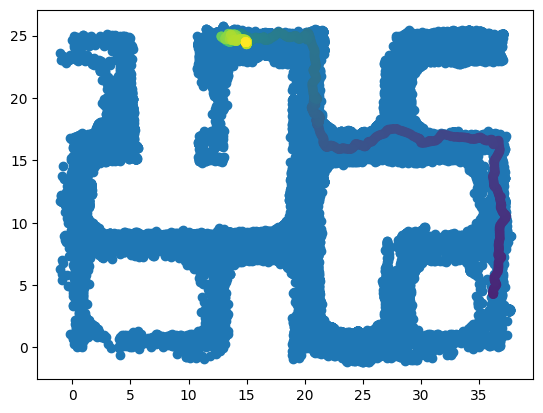

In [5]:
plt.scatter(dataset_trajectories[:, ::10, 0], dataset_trajectories[:, ::10, 1])

i = 1
plt.scatter(dataset_trajectories[i, :, 0], dataset_trajectories[i, :, 1], c=np.linspace(0.1, 1, 1001), vmin=0, vmax=1)

In [6]:
def trajectory_reward_function(states, next_states, target_trajectory):
    assert target_trajectory.dim() == 2 # (num_anchors, obs_dim)
    assert states.dim() == 2     # (num_states, obs_dim)
    assert states.shape == next_states.shape     # (num_states, obs_dim)
    
    all_states = torch.concat((states, next_states), dim=0)
    
    # print(all_states.shape)

    distances = (all_states[:, None] - target_trajectory[None, :]).pow(2).sum(dim=-1)
    min_info = distances.min(dim=-1)
    min_distances, clostest_anchor = min_info.values, min_info.indices

    r = (min_distances < 2) * clostest_anchor

    r = r.reshape(2, -1)
    r = r[1] - r[0]
    r = torch.clip(r, -2, 2)
    
    return r

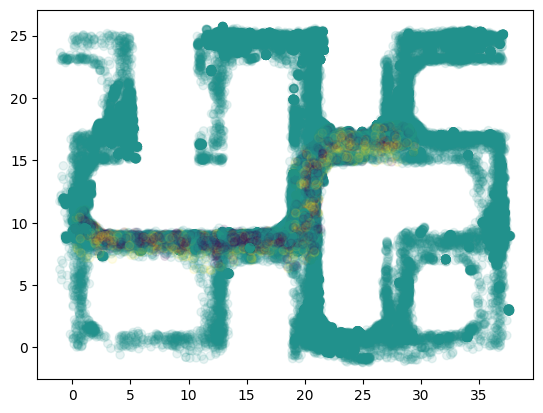

In [18]:
i = 15

target_trajectory = dataset_trajectories[i, ::][..., :2].to(device)
states = dataset_trajectories[:, :1000:10, :2].reshape(-1, 2).to(device)
next_states = dataset_trajectories[:, 1:1000:10, :2].reshape(-1, 2).to(device)




r = trajectory_reward_function(states, next_states, target_trajectory)


# print((r != 0).sum() / r.numel())

plt.scatter(states[..., 0].cpu(), states[..., 1].cpu(), c=r.cpu(), alpha=0.1, vmin=-1, vmax=1)

In [8]:
r.min()

tensor(-2, device='cuda:0')